# Algoritmos Sequenciales

- LCSS
- ERS
- ERP

In [2]:
import geojsonio
import stmeasures
import utils

g_similar = utils.read_file('../assets/map.geojson')
g_similar_u = utils.read_file('../assets/u.geojson')

## Trayectorias a utilizar

In [3]:
t1 = [(trajectory[1], trajectory[0]) for trajectory in g_similar['features'][0]['geometry']['coordinates']]
t2 = [(trajectory[1], trajectory[0]) for trajectory in g_similar['features'][1]['geometry']['coordinates']]

In [11]:
_ = geojsonio.display(stmeasures.geojsonio_contents(trajectories=[t1,t2], indexes=[1,2]))

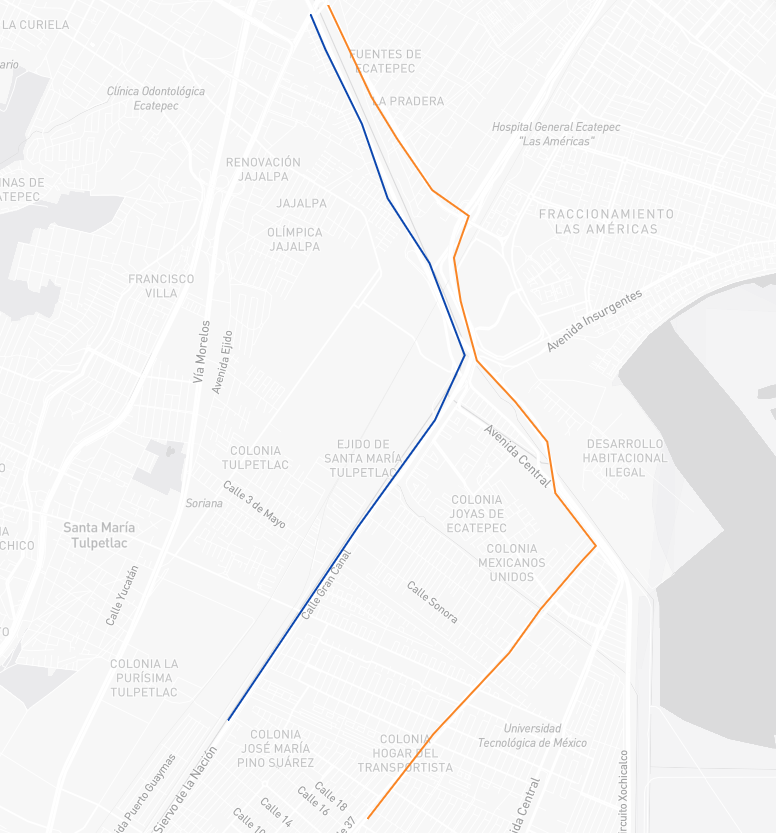

In [36]:
def calculate_sequential(a, b, display=True):
    print(f"Resultado LCSS: {stmeasures.distance(a, b, stmeasures.Algorithms.LCSS)}")
    print(f"Resultado ERS: {stmeasures.distance(a, b, stmeasures.Algorithms.ERS)}")
    print(f"Resultado ERP: {stmeasures.distance(a, b, stmeasures.Algorithms.ERP)}")
    
    if display:
        _ = geojsonio.display(stmeasures.geojsonio_contents(trajectories=[a, b], indexes=[1, 2]))

In [22]:
calculate_sequential(t1, t2)

Resultado LCSS: 0.5555555555555556
Resultado ERS: 18.0
Resultado ERP: 948.7763772085405


### Trayectoria auxiliar

In [28]:
g_line = utils.read_file('../assets/single_line.geojson')
t = [(trajectory[1], trajectory[0]) for trajectory in g_line['features'][0]['geometry']['coordinates']]

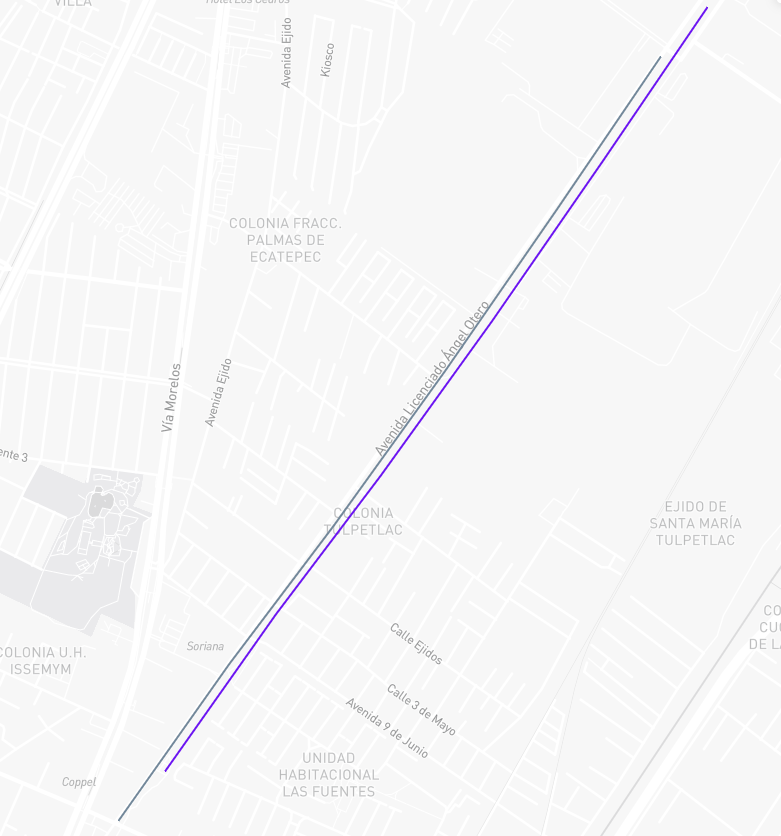

#### Proximidad geográfica


In [37]:
addlon = 0.001
addlat = 0.001
tp = [(coords[0] + addlon, coords[1] + addlat) for coords in t]
calculate_sequential(t, tp)

Resultado LCSS: 1.0
Resultado ERS: 6.0
Resultado ERP: 0.012000000000035982


In [38]:
addlon = 1
addlat = 1
tp = [(coords[0] + addlon, coords[1] + addlat) for coords in t]
calculate_sequential(t, tp)

Resultado LCSS: 1.0
Resultado ERS: 3.0
Resultado ERP: 12.0


In [39]:
addlon = -1
addlat = 1
tp = [(coords[0] + addlon, coords[1] + addlat) for coords in t]
calculate_sequential(t, tp)

Resultado LCSS: 1.0
Resultado ERS: 3.0
Resultado ERP: 12.0


In [40]:
addlon = -1
addlat = -1
tp = [(coords[0] + addlon, coords[1] + addlat) for coords in t]
calculate_sequential(t, tp)

Resultado LCSS: 1.0
Resultado ERS: 3.0
Resultado ERP: 12.0


In [41]:
addlon = 1
addlat = -1
tp = [(coords[0] + addlon, coords[1] + addlat) for coords in t]
calculate_sequential(t, tp)

Resultado LCSS: 1.0
Resultado ERS: 3.0
Resultado ERP: 12.0


#### Número de elementos

In [43]:
calculate_sequential(t, tp[:-1])

Resultado LCSS: 0.8333333333333334
Resultado ERS: 2.0
Resultado ERP: 128.60699274796693


In [44]:
calculate_sequential(t, tp[:-2])

Resultado LCSS: 0.6666666666666666
Resultado ERS: 3.0
Resultado ERP: 245.21644878736367


In [47]:
calculate_sequential(t, tp[::-1], display=False)

Resultado LCSS: 0.5
Resultado ERS: 0.0
Resultado ERP: 12.0
